## Comparativo de Algoritmos de Busca

Executa todos os algoritmos registrados com as ordens `"asc"` e `"desc"` e exibe
uma tabela e um gráfico comparando:
- **Movimentos** — tamanho da solução encontrada
- **Nós expandidos** — esforço de busca
- **Máx. de abertos** — pico de memória da lista abertos

> **Para adicionar um novo algoritmo:** edite apenas a célula do `REGISTRY` abaixo.

Código dos algoritmos: `algorithms/`

In [ ]:
import sys, importlib
from pathlib import Path

sys.path.insert(0, str(Path("algorithms").resolve()))

import backtracking as bt
import bfs as bfs_mod
import dfs as dfs_mod
from utils import INITIAL_STATE

for mod in (bt, bfs_mod, dfs_mod):
    importlib.reload(mod)


# ── wrappers: normalizam o retorno de cada algoritmo ─────────────────────────
# Resultado padronizado: {solved, moves, expanded, max_open, applied}
#   solved    → bool
#   moves     → int  | None (sem solução)
#   expanded  → int  | None (não rastreado)
#   max_open  → int  | None (não rastreado)
#   applied   → list | None

def _run_backtracking(order, depth_limit=36):
    r = bt.backtracking(INITIAL_STATE, depth_limit=depth_limit, order=order)
    if r is None:
        return dict(solved=False, moves=None, expanded=None, max_open=None, applied=None)
    path, applied, tried = r
    return dict(solved=True, moves=len(applied), expanded=None, max_open=None, applied=applied)

def _run_bfs(order, pruning=True):
    r = bfs_mod.bfs(INITIAL_STATE, order=order, pruning=pruning)
    if r is None or r[0] is None:
        return dict(solved=False, moves=None, expanded=None, max_open=None, applied=None)
    path, applied, stats, *_ = r
    return dict(solved=True, moves=len(applied),
                expanded=stats["expanded"], max_open=stats["max_open"], applied=applied)

def _run_dfs(order, pruning=True):
    r = dfs_mod.dfs(INITIAL_STATE, order=order, pruning=pruning)
    if r is None or r[0] is None:
        return dict(solved=False, moves=None, expanded=None, max_open=None, applied=None)
    path, applied, stats, *_ = r
    return dict(solved=True, moves=len(applied),
                expanded=stats["expanded"], max_open=stats["max_open"], applied=applied)


# ── REGISTRY: adicione novos algoritmos aqui ──────────────────────────────────
# Cada entrada: {"label": str, "run": callable(order) → resultado padronizado}
REGISTRY = [
    {"label": "Backtracking (p=36)", "run": _run_backtracking},
    {"label": "BFS (com poda)",      "run": _run_bfs},
    {"label": "DFS (com poda)",      "run": _run_dfs},
]

ORDERS = ["asc", "desc"]

print(f"{len(REGISTRY)} algoritmo(s) registrado(s): "
      f"{', '.join(e['label'] for e in REGISTRY)}")


3 algoritmo(s) registrado(s): Backtracking (p=36), BFS (com poda), DFS (com poda)


In [2]:
# Executa todos os algoritmos × ordens e coleta os resultados
results = []
for entry in REGISTRY:
    for order in ORDERS:
        print(f"  Rodando {entry['label']} (order={order!r})...", end=" ")
        r = entry["run"](order)
        results.append({"label": entry["label"], "order": order, **r})
        status = f"{r['moves']} mov." if r["solved"] else "sem solução"
        print(status)

print(f"\nTotal: {len(results)} combinações")


  Rodando Backtracking (p=36) (order='asc')... 36 mov.
  Rodando Backtracking (p=36) (order='desc')... 36 mov.
  Rodando BFS (com poda) (order='asc')... 16 mov.
  Rodando BFS (com poda) (order='desc')... 16 mov.
  Rodando DFS (com poda) (order='asc')... 38 mov.
  Rodando DFS (com poda) (order='desc')... 38 mov.

Total: 6 combinações


In [3]:
# Tabela comparativa
best_moves = min((r["moves"] for r in results if r["solved"]), default=None)

def _fmt(v, suffix=""):
    return f"{v}{suffix}" if v is not None else "—"

cols   = ["Algoritmo", "ORDER", "Movimentos", "Nós expandidos", "Máx. abertos"]
widths = [24, 6, 12, 16, 14]

def _hline(l, m, r, f):
    return l + m.join(f * w for w in widths) + r

print(_hline("┌", "┬", "┐", "─"))
print("│" + "│".join(h.center(w) for h, w in zip(cols, widths)) + "│")
print(_hline("├", "┼", "┤", "─"))

for r in results:
    optimal = r["solved"] and r["moves"] == best_moves
    moves_str = _fmt(r["moves"], " ★" if optimal else "")
    row = [
        r["label"],
        r["order"],
        moves_str,
        _fmt(r["expanded"]),
        _fmt(r["max_open"]),
    ]
    print("│" + "│".join(str(v).center(w) for v, w in zip(row, widths)) + "│")

print(_hline("└", "┴", "┘", "─"))
print("\n★ = solução ótima (menor número de movimentos encontrado)")
print("— = métrica não rastreada pelo algoritmo")


┌────────────────────────┬──────┬────────────┬────────────────┬──────────────┐
│       Algoritmo        │ORDER │ Movimentos │ Nós expandidos │ Máx. abertos │
├────────────────────────┼──────┼────────────┼────────────────┼──────────────┤
│  Backtracking (p=36)   │ asc  │     36     │       —        │      —       │
│  Backtracking (p=36)   │ desc │     36     │       —        │      —       │
│     BFS (com poda)     │ asc  │    16 ★    │      273       │      29      │
│     BFS (com poda)     │ desc │    16 ★    │      273       │      29      │
│     DFS (com poda)     │ asc  │     38     │      196       │     136      │
│     DFS (com poda)     │ desc │     38     │      196       │     136      │
└────────────────────────┴──────┴────────────┴────────────────┴──────────────┘

★ = solução ótima (menor número de movimentos encontrado)
— = métrica não rastreada pelo algoritmo


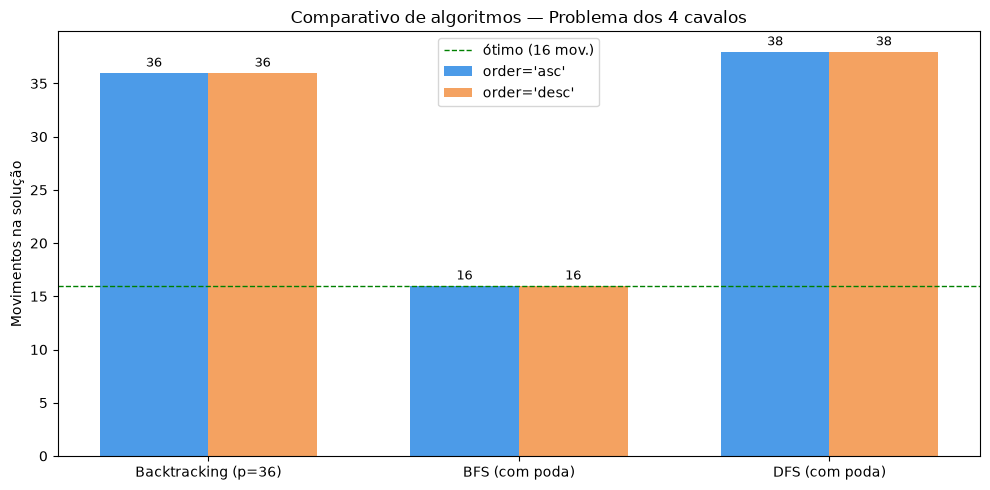

In [4]:
import matplotlib.pyplot as plt
import numpy as np

solved = [r for r in results if r["solved"]]
labels_all = [e["label"] for e in REGISTRY]
orders     = ORDERS

# Agrupa movimentos por (label, order) para o gráfico de barras agrupadas
data = {label: [] for label in labels_all}
for label in labels_all:
    for order in orders:
        match = next((r for r in results if r["label"] == label and r["order"] == order), None)
        data[label].append(match["moves"] if match and match["solved"] else 0)

x      = np.arange(len(labels_all))
n_ord  = len(orders)
width  = 0.35
offset = np.linspace(-(n_ord - 1) / 2, (n_ord - 1) / 2, n_ord) * width
colors = ["#4C9BE8", "#F4A261"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (order, off, color) in enumerate(zip(orders, offset, colors)):
    vals = [data[label][i] for label in labels_all]
    bars = ax.bar(x + off, vals, width, label=f"order={order!r}", color=color)
    for bar, val in zip(bars, vals):
        if val:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    str(val), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_all, fontsize=10)
ax.set_ylabel("Movimentos na solução")
ax.set_title("Comparativo de algoritmos — Problema dos 4 cavalos")
ax.legend()
ax.axhline(best_moves, color="green", linestyle="--", linewidth=1,
           label=f"ótimo ({best_moves} mov.)")
ax.legend()
plt.tight_layout()
plt.show()
